# Hedging with Real SPX Option Data

## Introduction

In this notebook we will implement a one-day delta hedging strategy, using real option data. At the end we will compare their effectiveness. Delta hedging is used to protect portofolio's against price movements in the underlying asset. This method helps to manage risk, especially in large portofolios. In this notebook we will be working with real data of options in the timeframe 01/02/2023-28/02/2023. The notebook will be made up of different steps each buidling on the previous steps. It is important to run all cells in the correct order.

### PreWork
Before being able to perform the real hedging we need to do some preparations. We will be using the given data, under "option20230201_20230228.csv".

In [375]:
"""
All imports needed for the notebook.
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

Cell_2_run = False
step_3 = False

In [376]:
# -----------------------------
# Load data
# -----------------------------
df_raw = pd.read_csv("option20230201_20230228.csv")
rows_raw = len(df_raw)

# -----------------------------
# Convert dates to datetime
# -----------------------------
df_raw["date"] = pd.to_datetime(df_raw["date"])
df_raw["exdate"] = pd.to_datetime(df_raw["exdate"])

# -----------------------------
# Keep calls only
# -----------------------------
df_raw = df_raw[df_raw["cp_flag"] == "C"].copy()
rows_calls_only = len(df_raw)

# -----------------------------
# Rescale strikes if needed
# -----------------------------
if "strike_price" in df_raw.columns:
    df_raw["strike_price"] = df_raw["strike_price"] / 1000.0

# -----------------------------
# Construct option midquote V_t
# -----------------------------
df_raw["V_t"] = (df_raw["best_bid"] + df_raw["best_offer"]) / 2.0

# -----------------------------
# Market implied vol (sigma_mkt) is impl_volatility
# -----------------------------
# (No rename required, but we’ll report it as sigma_mkt)
df_raw = df_raw[df_raw["impl_volatility"].notna()]
df_raw = df_raw[df_raw["impl_volatility"] > 0]

# -----------------------------
# Compute dte and tau
# -----------------------------
df_raw["dte"] = (df_raw["exdate"] - df_raw["date"]).dt.days
df_raw = df_raw[df_raw["dte"] > 0]
df_raw["tau"] = df_raw["dte"] / 365.0

# -----------------------------
# Keep only the useful columns
# -----------------------------
final_columns = [
    "optionid", "date", "exdate", "tau", "dte",
    "strike_price",
    "V_t",
    "impl_volatility",
    "delta"
]

final_columns = [c for c in final_columns if c in df_raw.columns]
df = df_raw[final_columns].copy()

# -----------------------------
# Required reporting
# -----------------------------
n_unique_dates = df["date"].nunique() if "date" in df.columns else np.nan
n_unique_expiries = df["exdate"].nunique() if "exdate" in df.columns else np.nan

missing_rate_Vt = df["V_t"].isna().mean() if "V_t" in df.columns else np.nan
missing_rate_sigma = df["impl_volatility"].isna().mean() if "impl_volatility" in df.columns else np.nan
missing_rate_delta = df["delta"].isna().mean() if "delta" in df.columns else np.nan

print("=== REQUIRED REPORTING ===")
print(f"Row count (before filtering to calls): {rows_raw}")
print(f"Row count (after filtering to calls):  {rows_calls_only}")
print(f"Unique trading dates:                 {n_unique_dates}")
print(f"Unique expiries:                      {n_unique_expiries}")
print(f"Missing rate V_t:                     {missing_rate_Vt:.6f}")
print(f"Missing rate sigma_mkt (impl_volatility): {missing_rate_sigma:.6f}")
print(f"Missing rate delta:                   {missing_rate_delta:.6f}")
print(f"Row count for final dataset:          {len(df)}")
print(f"Final columns kept:                   {df.columns.tolist()}")

=== REQUIRED REPORTING ===
Row count (before filtering to calls): 175301
Row count (after filtering to calls):  175301
Unique trading dates:                 19
Unique expiries:                      67
Missing rate V_t:                     0.000000
Missing rate sigma_mkt (impl_volatility): 0.000000
Missing rate delta:                   0.000000
Row count for final dataset:          153728
Final columns kept:                   ['optionid', 'date', 'exdate', 'tau', 'dte', 'strike_price', 'V_t', 'impl_volatility', 'delta']


We now have a clean dataset with the following columns:


optionid; unique identifier for a specific call option.

date; current date.

exdate; expiration date of the option.

tau; $\tau$ time to expiration date expressed in years.

strike_price; the exercise price of the option.

V_t; $V_t$

impl_volatitility; $\sigma_{mkt}$

delta; $\delta$

## Constructing one day change $\Delta V_t$

Now that we have a fully cleaned up dataset we can find the one-day option change.

In [377]:
if Cell_2_run == False:
    Cell_2_run = True

    df = df.sort_values(["optionid", "date"]).copy()
    df = df.drop_duplicates(subset=["optionid", "date"], keep="last").copy()
    rows_before = len(df)
    contracts_before = df["optionid"].nunique()
    df["V_t_plus_1"] = df.groupby("optionid")["V_t"].shift(-1)
    df["dV_t"] = df["V_t_plus_1"] - df["V_t"]
    rows_retained = df["dV_t"].notna().sum()
    df = df[df["dV_t"].notna()].copy()

    contracts_after = df["optionid"].nunique()

    print("=== STEP 2 REPORT ===")
    print(f"Rows before constructing ΔV_t: {rows_before}")
    print(f"Rows retained after constructing ΔV_t: {rows_retained}")
    print(f"Rows dropped (no V_{'{'}t+1{'}'} or missing V): {rows_before - rows_retained}")

    print(f"Unique contracts before ΔV_t: {contracts_before}")
    print(f"Unique contracts retained after ΔV_t: {contracts_after}")
    print(f"Percentage of contracts dropped entirely (only 1 obs or missing V): {(contracts_before - contracts_after)/contracts_before:.4f}")

    print("\nV_t summary:")
    print(df["V_t"].describe())

    print("\nΔV_t summary:")
    print(df["dV_t"].describe())

=== STEP 2 REPORT ===
Rows before constructing ΔV_t: 153728
Rows retained after constructing ΔV_t: 141619
Rows dropped (no V_{t+1} or missing V): 12109
Unique contracts before ΔV_t: 12109
Unique contracts retained after ΔV_t: 11593
Percentage of contracts dropped entirely (only 1 obs or missing V): 0.0426

V_t summary:
count    141619.000000
mean        430.754198
std         578.585187
min           0.025000
25%          36.400000
50%         206.450000
75%         600.850000
max        4022.700000
Name: V_t, dtype: float64

ΔV_t summary:
count    141619.000000
mean         -6.315655
std          27.128320
min        -170.300000
25%         -22.200000
50%          -2.150000
75%           5.100000
max          70.200000
Name: dV_t, dtype: float64


We see that $\approx 5 \%$ of the contracts is dropped. Most likely because they consisted only of a single trading day. In which case $\Delta V_t$ can not be calculated.

When looking at the summary of $V_t$ a few things are striking. Note the large standard deviation with respect to the mean. This indicates a wide range, the fact that the mean is larger than the median indicated a right skewed distribution, with expesince options.

Also the $\Delta V_t$ has a relatively high standard deviation, which indicated noisy daily price changes. The negative average daily price change is most likely due to options losing value over time.

## Calulcating price on the underlying asset $S_t$

Merge coverage: 1.0

Summary of S_t:
count    141619.000000
mean       4085.065277
std          64.690452
min        3970.040000
25%        4012.320000
50%        4090.460000
75%        4136.480000
max        4179.760000
Name: Close, dtype: float64

Summary of ΔS_t:
count    141619.000000
mean         -8.476981
std          37.850399
min         -81.750000
25%         -42.280000
50%         -11.320000
75%          12.200000
max          60.550000
Name: dS_t, dtype: float64


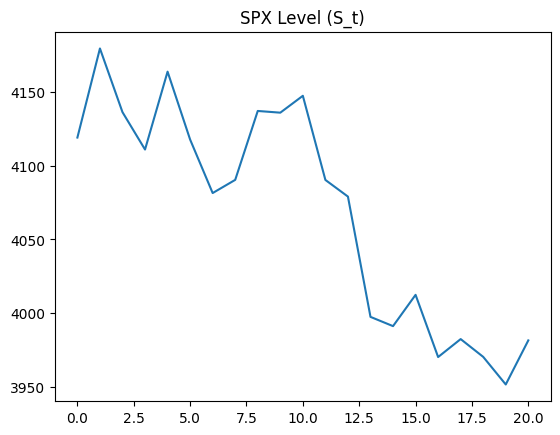

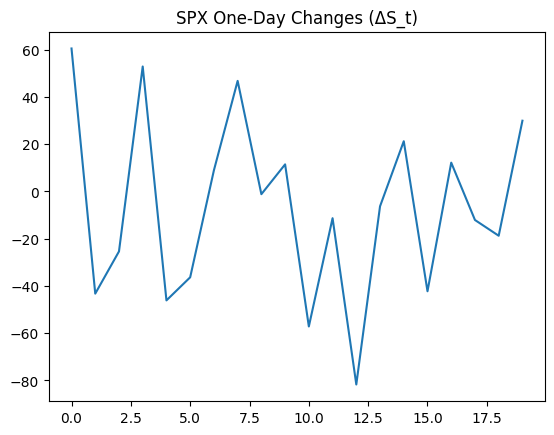

In [378]:
start = "2023-02-01"
end = "2023-03-02"
d1 = pd.Timestamp(start).strftime("%Y%m%d")
d2 = pd.Timestamp(end).strftime("%Y%m%d")
url = f"https://stooq.com/q/d/l/?s=^spx&d1={d1}&d2={d2}&i=d"

if step_3:
    print("dS_t already exists in df, skipping SPX merge.")
else:
    step_3 = True
    spx = pd.read_csv(url, parse_dates=["Date"]).sort_values("Date")
    spx["dS_t"] = spx["Close"].shift(-1) - spx["Close"]

    df_temp = df.copy()

    df_step3 = df_temp.merge(
        spx[["Date", "Close", "dS_t"]],
        left_on="date",
        right_on="Date",
        how="left"
    )
    df_step3 = df_step3.drop(columns=["date"])

    merge_coverage = df_step3["dS_t"].notna().mean()

    print("Merge coverage:", merge_coverage)

    print("\nSummary of S_t:")
    print(df_step3['Close'].describe())

    print("\nSummary of ΔS_t:")
    print(df_step3["dS_t"].describe())

    plt.figure()
    spx["Close"].plot()
    plt.title("SPX Level (S_t)")
    plt.show()

    plt.figure()
    spx["dS_t"].plot()
    plt.title("SPX One-Day Changes (ΔS_t)")
    plt.show()

    df["dS_t"] = df_step3["dS_t"]

We will again analyse the plots and summaries of both our $\Delta S_t$ and $S_t.$ We firstly will focus on $S_t$,
we see that the standard deviation is low compared to the mean, which gives us the idea that the underlying asset of the European options are stable. In the plot of $S_t$ over time, we see a clear decreasing patern. Which is then emphatized by the observed negative mean for $\Delta S_t$. Which indicates that on average the underlying asset decreases in value. This also explains the earlier found negative mean for $\Delta V_t$, since when the underlying asset for an European call option decreases in value, the call option itself does to due to its positive correlation.

## Extracting $r_t(\tau),$ using NSS.

In the following section we will derive a smooth risk-free zero-rate curve for every trading day $t$. We then can find a continuously-compounded zero rate $r_t(\tau).$ Which will be usefull later. The risk-free dataset used is the US treasury par yields.

In [379]:
url = (
"https://home.treasury.gov/resource-center/data-chart-center/interest-rates/"
"daily-treasury-rate-archives/par-yield-curve-rates-2020-2023.csv"
)
treasury = pd.read_csv(url)
treasury["date"] = pd.to_datetime(treasury["date"]).dt.normalize()

In [380]:
dates = (
    pd.to_datetime(df["date"])
      .dropna()
      .drop_duplicates()
      .sort_values()
)

df_y = treasury.copy()
df_y["date"] = pd.to_datetime(df_y["date"])
df_y = df_y.sort_values("date").set_index("date")

yield_cols = [c for c in df_y.columns if c != "date"]
df_y[yield_cols] = df_y[yield_cols] / 100.0

# Build in forward fill function, to fill missing treasury observations.
y_panel = df_y.reindex(dates).ffill()

y_panel = y_panel.bfill(limit=None)
print(y_panel.columns)

Index(['1 mo', '2 mo', '3 mo', '4 mo', '6 mo', '1 yr', '2 yr', '3 yr', '5 yr',
       '7 yr', '10 yr', '20 yr', '30 yr'],
      dtype='str')


In [381]:
def g1(tau, lam):
    tau = np.asarray(tau, dtype=float)
    lam = np.asarray(lam, dtype=float)
    x = tau / lam
    return np.where(np.isclose(x, 0.0), 1.0, (1.0 - np.exp(-x)) / x)

def g2(tau, lam):
    tau = np.asarray(tau, dtype=float)
    lam = np.asarray(lam, dtype=float)
    return g1(tau, lam) - np.exp(-tau/lam)

def g3(tau, lam):
    tau = np.asarray(tau, dtype=float)
    lam = np.asarray(lam, dtype=float)
    return g1(tau, lam) - np.exp(-tau/lam)

def X_matrix(maturities, tau1, tau2):
    m = np.asarray(maturities, dtype=float)
    X = np.column_stack([
        np.ones_like(m),
        g1(m, tau1),
        g2(m, tau1),
        g3(m, tau2),
    ])
    return X

def beta_hat(X, y):
    y = np.asarray(y, dtype=float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta

def fit_nss_gridsearch(maturities, y_obs, tau_grid1, tau_grid2=None):
    m = np.asarray(maturities, float)
    y = np.asarray(y_obs, float)

    if tau_grid2 is None:
        tau_grid2 = tau_grid1

    best = {"sse": np.inf, "beta": None, "tau1": None, "tau2": None}

    for tau1 in tau_grid1:
        for tau2 in tau_grid2:
            if tau2 < tau1:
                continue

            X = X_matrix(m, tau1, tau2)
            beta = beta_hat(X, y)
            resid = y - X @ beta
            sse = float(resid @ resid)

            if sse < best["sse"]:
                best.update({"sse": sse, "beta": beta, "tau1": float(tau1), "tau2": float(tau2)})

    return best["beta"], best["tau1"], best["tau2"], best["sse"]

tau_grid = np.linspace(0.1, 10, 40)

params_list = []
maturities = np.array([
    1/12, 2/12, 3/12, 4/12, 6/12,
    1, 2, 3, 5, 7, 10, 20, 30
])


for date, row in y_panel.iterrows():

    y_obs = row.values.astype(float)
    beta, tau1_hat, tau2_hat, sse = fit_nss_gridsearch(
        maturities,
        y_obs,
        tau_grid
    )

    params_list.append({
        "date": date,
        "beta0": beta[0],
        "beta1": beta[1],
        "beta2": beta[2],
        "beta3": beta[3],
        "tau1": tau1_hat,
        "tau2": tau2_hat,
        "sse": sse
    })

df_params = pd.DataFrame(params_list)

In [382]:
date0 = df_params["date"].iloc[0]
row_y = y_panel.loc[date0].values

params0 = df_params[df_params["date"] == date0].iloc[0]
tau_test = maturities
y_fit = (
    params0.beta0
    + params0.beta1 * g1(tau_test, params0.tau1)
    + params0.beta2 * g2(tau_test, params0.tau1)
    + params0.beta3 * g3(tau_test, params0.tau2)
)


In [383]:
df["date"] = pd.to_datetime(df["date"])
df_params["date"] = pd.to_datetime(df_params["date"])

df = df.merge(df_params, on="date", how="left")

tau = df["tau"].to_numpy()

df["yhat"] = (
    df["beta0"]
    + df["beta1"] * g1(tau, df["tau1"])
    + df["beta2"] * g2(tau, df["tau1"])
    + df["beta3"] * g3(tau, df["tau2"])
)

In [384]:
def r_tau(tau, y_hat):
    return 2*np.log(1+y_hat/2)

def P_tau(tau, y_hat):
    return np.e**(-r_tau(tau, y_hat)*tau)

def F_tau(tau, y_hat, S, q=0):
    return S*np.e**(-(r_tau(tau, y_hat)-q)*tau)

df["risk_free_rate"] = r_tau(df["tau"], df["yhat"])
df["discount_factor"] = P_tau(df["tau"], df["yhat"])
print("Summary of P_t​(τ):")
print(df["discount_factor"].describe())
print("Summary of r_t​(τ):")
print(df["risk_free_rate"].describe())

Summary of P_t​(τ):
count    141619.000000
mean          0.983586
std           0.024094
min           0.818016
25%           0.981050
50%           0.991363
75%           0.997126
max           0.999759
Name: discount_factor, dtype: float64
Summary of r_t​(τ):
count    141619.000000
mean          0.046770
std           0.001885
min           0.034388
25%           0.045472
50%           0.046639
75%           0.048139
max           0.050735
Name: risk_free_rate, dtype: float64


We see that the discount factor are slightly below $1$, which is what we expect for a dataset with such a small timeframe. Since for both the standard deviation is quite low, we can conclude that rates are stable. We also see that $P_t(\tau)$ and $r_t(\tau)$ are both finite. 

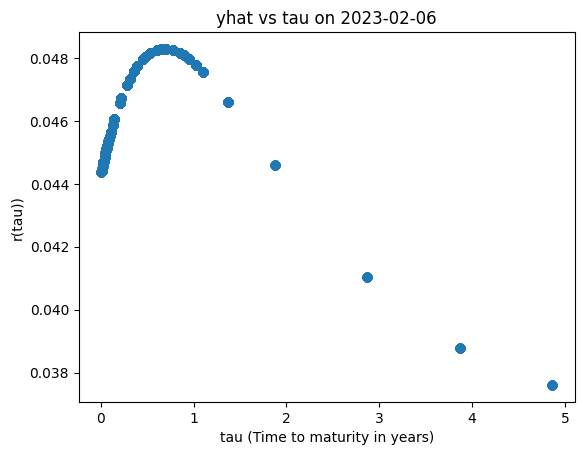

In [385]:
single_day = df["date"].unique()[1]

df_day = df[df["date"] == single_day]
plt.figure()
plt.scatter(df_day["tau"], 2*np.log(1+df_day["yhat"]/2), label="r(tau)")
plt.xlabel("tau (Time to maturity in years)")
plt.ylabel("r(tau))")
plt.title(f"yhat vs tau on {single_day.date()}")
plt.show()

=== Summary of baseline residual ε_t(Δ^BS) ===
N: 120312
Mean: -1.1967628162516677
Std: 38.58502846691986
RMSE: 38.60342327438903
Min: -216.24592921999997
Max: 139.24861324999995
Percentiles (1,5,50,95,99): [-1.01976703e+02 -6.82524163e+01 -8.36589000e-03  6.60352520e+01
  9.82884541e+01]
Rows in slice: 122
Unique strikes: 122


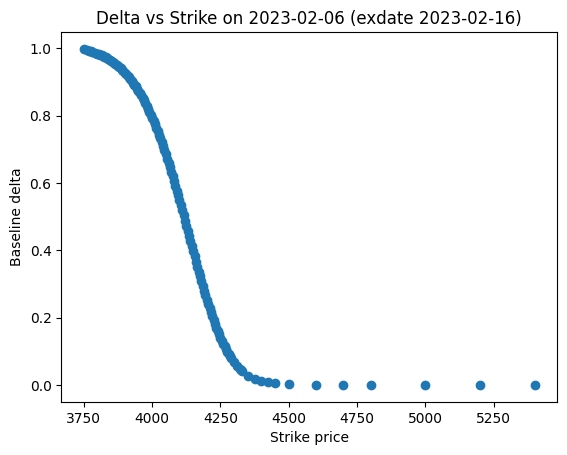

In [386]:
df["delta_BS"] = df["delta"]
df["eps_BS"] = df["dV_t"] - df["delta_BS"] * df["dS_t"]
df_eps = df.dropna(subset=["eps_BS"]).copy()

eps = df_eps["eps_BS"]

print("=== Summary of baseline residual ε_t(Δ^BS) ===")
print("N:", len(eps))
print("Mean:", eps.mean())
print("Std:", eps.std())
print("RMSE:", np.sqrt(np.mean(eps**2)))
print("Min:", eps.min())
print("Max:", eps.max())
print("Percentiles (1,5,50,95,99):",
      np.percentile(eps, [1,5,50,95,99]))

chosen_day = pd.Timestamp("2023-02-06")
chosen_exdate = pd.Timestamp("2023-02-16")

g = df[(df["date"] == chosen_day) & (df["exdate"] == chosen_exdate)].copy()
g = g.dropna(subset=["strike_price", "delta"])

print("Rows in slice:", len(g))
print("Unique strikes:", g["strike_price"].nunique())

plt.figure()
plt.scatter(g["strike_price"], g["delta"])
plt.xlabel("Strike price")
plt.ylabel("Baseline delta")
plt.title(f"Delta vs Strike on {chosen_day.date()} (exdate {chosen_exdate.date()})")
plt.show()

The previous plot describes the baseline delta against the strike price for options expiring on 16-02-2026, on 06 february 2026. We see a monotonic decreasing pattern. Low strike price have deltas close to one, and the other way around.
Our $\epsilon_t(\Delta ^{BS})$ has a negative mean, which indicates (minimal) systematic bias.

In [387]:
"""
Filter described in Hull J. and White (2016).
"""

df_filtered = df_eps.copy()
df_filtered = df_filtered[df_filtered["delta_BS"] > 0.05]
df_filtered = df_filtered[df_filtered["delta_BS"] < 0.95]
print(df_eps.columns)
df_filtered = df_filtered[df_filtered["dte"] > 14]

Index(['optionid', 'date', 'exdate', 'tau', 'dte', 'strike_price', 'V_t',
       'impl_volatility', 'delta', 'V_t_plus_1', 'dV_t', 'dS_t', 'beta0',
       'beta1', 'beta2', 'beta3', 'tau1', 'tau2', 'sse', 'yhat',
       'risk_free_rate', 'discount_factor', 'delta_BS', 'eps_BS'],
      dtype='str')


In [390]:
df_b = df_filtered.copy()

delta_edges = np.linspace(0.05, 0.95, 10)

df_b["delta_bucket"] = pd.cut(
    df_b["delta_BS"],
    bins=delta_edges,
    include_lowest=False,
    right=True
)

df_b["delta_bucket_id"] = pd.cut(
    df_b["delta_BS"],
    bins=delta_edges,
    labels=range(1, 10),
    include_lowest=False,
    right=True
).astype(int)

dmin = df_b["dte"].min()
dmax = df_b["dte"].max()

mat_edges = np.linspace(dmin, dmax, 8)

df_b["mat_bucket"] = pd.cut(
    df_b["dte"],
    bins=mat_edges,
    include_lowest=True,
    right=True
)

df_b["mat_bucket_id"] = pd.cut(
    df_b["dte"],
    bins=mat_edges,
    labels=range(1, 8),
    include_lowest=True,
    right=True
).astype(int)
print(df_b.columns)
n_buckets_used = df_b.groupby(["delta_bucket_id", "mat_bucket_id"]).size().shape[0]
print("Buckets with data:", n_buckets_used, "out of 63")

Index(['optionid', 'date', 'exdate', 'tau', 'dte', 'strike_price', 'V_t',
       'impl_volatility', 'delta', 'V_t_plus_1', 'dV_t', 'dS_t', 'beta0',
       'beta1', 'beta2', 'beta3', 'tau1', 'tau2', 'sse', 'yhat',
       'risk_free_rate', 'discount_factor', 'delta_BS', 'eps_BS',
       'delta_bucket', 'delta_bucket_id', 'mat_bucket', 'mat_bucket_id'],
      dtype='str')
Buckets with data: 54 out of 63


In [391]:
if "eps_BS" not in df_filtered.columns:
    df_filtered["delta_BS"] = df_filtered["delta"]
    df_filtered["eps_BS"] = df_filtered["dV_t"] - df_filtered["delta_BS"] * df_filtered["dS_t"]

df_final = df_filtered.dropna(subset=["eps_BS"]).copy()

SSE_total = np.sum(df_final["eps_BS"]**2)

print("=== Final filtered sample performance ===")
print("N:", len(df_final))
print("Total SSE(Δ^BS):", SSE_total)

=== Final filtered sample performance ===
N: 74821
Total SSE(Δ^BS): 103559756.18135235


After using the standardized filters this is the baseline for $SSE(\Delta^{BS}).$

In [392]:
if "delta_bucket_id" not in df_final.columns:
    delta_edges = np.linspace(0.05, 0.95, 10)
    df_final["delta_bucket_id"] = pd.cut(
        df_final["delta_BS"],
        bins=delta_edges,
        labels=False,
        include_lowest=False,
        right=True
        ) + 1

if "mat_bucket_id" not in df_final.columns:
    dmin, dmax = df_final["dte"].min(), df_final["dte"].max()
    mat_edges = np.linspace(dmin, dmax, 8)
    df_final["mat_bucket_id"] = pd.cut(
        df_final["dte"],
        bins=mat_edges,
        labels=False,
        include_lowest=True,
        right=True
    ) + 1


Buckets with data: 54 out of 63


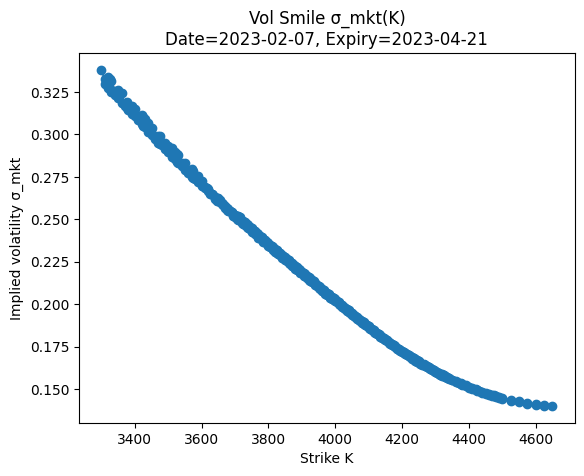

In [355]:
bucket = (
    df_final
    .groupby(["mat_bucket_id", "delta_bucket_id"])
    .agg(
        n=("eps_BS", "size"),
        SSE=("eps_BS", lambda x: float(np.sum(x**2))),
        MSE=("eps_BS", lambda x: float(np.mean(x**2)))
    )
    .reset_index()
)

# Make 7x9 tables (rows=maturity buckets, cols=delta buckets)
SSE_table = bucket.pivot(index="mat_bucket_id", columns="delta_bucket_id", values="SSE")
MSE_table = bucket.pivot(index="mat_bucket_id", columns="delta_bucket_id", values="MSE")

print("\nBuckets with data:", bucket.shape[0], "out of 63")

chosen_date = df_final["date"].mode().iloc[0]

tmp = df_final[df_final["date"] == chosen_date]
chosen_expiry = tmp["exdate"].value_counts().idxmax()

smile = df_final[(df_final["date"] == chosen_date) & (df_final["exdate"] == chosen_expiry)].copy()
smile = smile.sort_values("strike_price")

plt.figure()
plt.plot(smile["strike_price"], smile["impl_volatility"], marker="o", linestyle="-")
plt.xlabel("Strike K")
plt.ylabel("Implied volatility σ_mkt")
plt.title(f"Vol Smile σ_mkt(K)\nDate={chosen_date.date()}, Expiry={chosen_expiry.date()}")
plt.show()

The plot above plots the implied volatility on 02-07, for option with expire date 04-21, against there strike price.
This Volitality smile plot shows skewed smile. We see that low strike prices are paired with an high implied volatility.

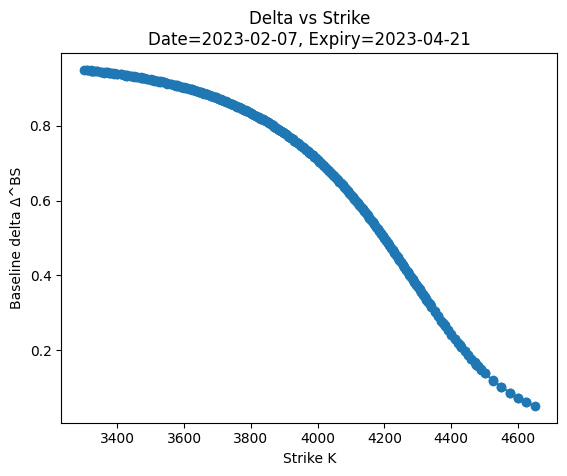

In [353]:
plt.figure()
plt.plot(smile["strike_price"], smile["delta_BS"], marker="o", linestyle="-")
plt.xlabel("Strike K")
plt.ylabel("Baseline delta Δ^BS")
plt.title(f"Delta vs Strike\nDate={chosen_date.date()}, Expiry={chosen_expiry.date()}")
plt.show()

The above figure plots de baseline delta against the strike price for options traded on 02-07 with expire date 21-04.

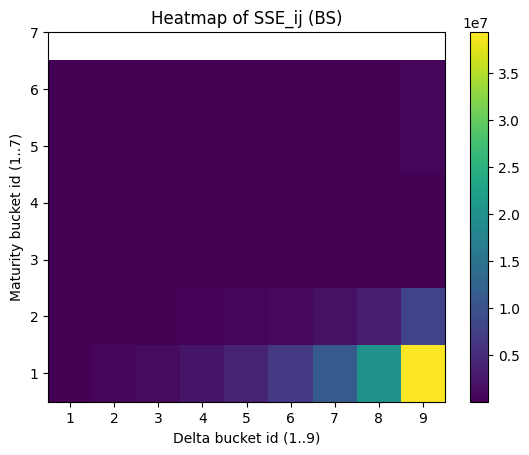

In [ ]:
plt.figure()
plt.imshow(SSE_table.values, aspect="auto", origin="lower")
plt.colorbar()
plt.xlabel("Delta bucket id (1..9)")
plt.ylabel("Maturity bucket id (1..7)")
plt.title("Heatmap of SSE_ij (BS)")
plt.xticks(ticks=np.arange(9), labels=np.arange(1,10))
plt.yticks(ticks=np.arange(7), labels=np.arange(1,8))
plt.show()

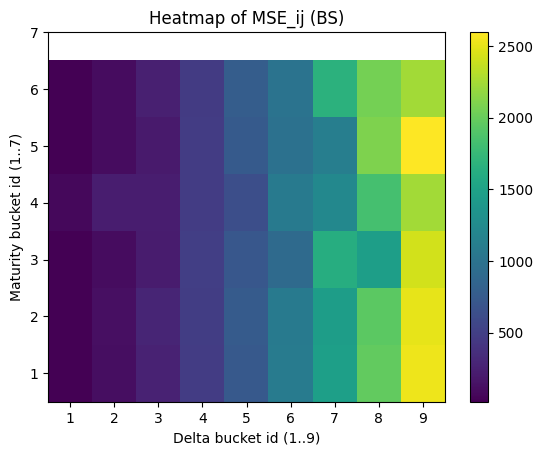

In [ ]:
plt.figure()
plt.imshow(MSE_table.values, aspect="auto", origin="lower")
plt.colorbar()
plt.xlabel("Delta bucket id (1..9)")
plt.ylabel("Maturity bucket id (1..7)")
plt.title("Heatmap of MSE_ij (BS)")
plt.xticks(ticks=np.arange(9), labels=np.arange(1,10))
plt.yticks(ticks=np.arange(7), labels=np.arange(1,8))
plt.show()

In [363]:
required = {"mat_bucket_id", "delta_bucket_id", "SSE", "MSE"}
missing = required - set(bucket.columns)
if missing:
    raise ValueError(f"bucket is missing columns: {missing}")

total_sse = bucket["SSE"].sum()
total_n   = bucket["n"].sum()
total_mse = total_sse / total_n if total_n > 0 else np.nan

total_row = {
    "mat_bucket_id": "TOTAL",
    "delta_bucket_id": "TOTAL",
    "SSE": total_sse,
    "MSE": total_mse,
}
if "n" in bucket.columns:
    total_row["n"] = total_n

hedging_scoreboard = pd.concat(
    [pd.DataFrame([total_row]), bucket.copy()],
    ignore_index=True
)

hedging_scoreboard.to_csv("HedgingScoreboard.csv", index=False)
print("Saved HedgingScoreboard.csv")

Saved HedgingScoreboard.csv



Best sigma by SSE: 0.18


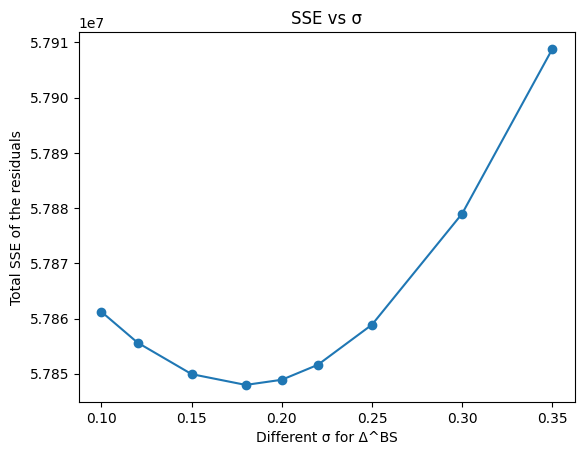

In [ ]:
def bs_delta(df, sigma):
    S = df["V_t"].to_numpy(dtype=float)
    K = df["strike_price"].to_numpy(dtype=float)
    tau = df["tau"].to_numpy(dtype=float)
    r = df["risk_free_rate"].to_numpy(dtype=float)

    eps = 1e-12
    tau = np.maximum(tau, eps)
    sig = max(float(sigma), eps)

    d1 = (np.log(S / K) + (r + 0.5 * sig**2) * tau) / (sig * np.sqrt(tau))
    return norm.cdf(d1)

def calc_sse(df, sigma_grid):
    out = []
    for sig in sigma_grid:
        delta_sig = bs_delta(df, sig)
        eps = df["dV_t"].to_numpy(dtype=float) - delta_sig * df["dS_t"].to_numpy(dtype=float)
        mask = np.isfinite(eps)
        eps = eps[mask]
        sq = eps**2

        out.append({
            "sigma": float(sig),
            "n": int(len(eps)),
            "SSE": float(sq.sum()),
            "MSE": float(sq.mean()) if len(sq) else np.nan,
            "RMSE": float(np.sqrt(sq.mean())) if len(sq) else np.nan,
        })
    return pd.DataFrame(out).sort_values("sigma")

sigmas = np.array([0.10, 0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.30, 0.35])

res = calc_sse(df_final, sigmas)
best = res.loc[res["SSE"].idxmin()]
print("\nBest sigma by SSE:", best["sigma"])

plt.figure()
plt.plot(res["sigma"], res["SSE"], marker="o")
plt.xlabel("Different σ for Δ^BS")
plt.ylabel("Total SSE of the residuals")
plt.title("SSE vs σ")
plt.show()

When ploting different values of $\sigma$ to calculate $\Delta^{BS}$ against the total SSE of the residuals we see a U-formed curve. In exercise 2 we have found that:
$$
\mathbf{E} \left[\int_0^T e^{-rt}\frac{1}{2}S_t^2\frac{\partial^2 C_t}{\partial S_t^2}\left(\sigma_t^2 - \sigma_{\text{imp}}^2\right)dt\right] = 0.
$$

From which we know that;
$$\epsilon_t \propto S_t^2\frac{\partial^2 C_t}{\partial S_t^2}\left(\sigma_t^2 - \sigma_{\text{imp}}^2\right)dt.$$

We have plotted $SSE = \sum \epsilon^2_t,$ so we look at

$$
\epsilon_t^2 \propto S_t^4(\frac{\partial^2 C_t}{\partial S_t^2})^2\left(\sigma_t^2 - \sigma_{\text{imp}}^2\right)^2.
$$

We see that SSE now is quadratic in  $\sigma_t^2 - \sigma_{\text{imp}}^2.$ So this parabolic curve we see in the plot above is exactly what we expect. 